In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import glob
from tqdm.auto import tqdm
import numpy as np
import os
import json

from semantic_state_estimator.constants import (
    RENDERS_DIR,
    TRUE_STATES_DIR,
    PROCESSED_DIR
)

def load_all(data_dir):
    seeds = os.listdir(os.path.join(data_dir, PROCESSED_DIR))

    all_renders = {}
    gts = {}
    preds = {seed: {} for seed in seeds}
    for renders_file in tqdm(glob.glob(os.path.join(data_dir, RENDERS_DIR, '*.npz'))):
        dp_name = os.path.splitext(os.path.basename(renders_file))[0]

        with np.load(renders_file) as data:
            all_renders[dp_name] = {k: data[k] for k in data}
        
        gt_path = os.path.join(data_dir, TRUE_STATES_DIR, dp_name + '.json')
        if os.path.exists(gt_path):
            with open(gt_path, 'r') as f:
                gts[dp_name] = json.load(f)
    
        for seed in seeds:
            pred_path = os.path.join(data_dir, PROCESSED_DIR, str(seed), dp_name + '.json')
            if os.path.exists(pred_path):
                with open(pred_path, 'r') as f:
                    preds[seed][dp_name] = json.load(f)
                first_item = next(iter(preds[seed][dp_name].values()))
                if isinstance(first_item, dict):
                    means = defaultdict(int)
                    num_viewpoints = len(preds[seed][dp_name])
                    for k, v in  preds[seed][dp_name].items():
                        preds.setdefault(seed + ' ' + k, {})[dp_name] = v
                        for predicate, score in v.items():
                            means[predicate] += score / num_viewpoints
                    preds[seed][dp_name] = means

    return all_renders, gts, preds

all_renders, gts, preds = load_all('examples/gw_grip/data_dir')

  0%|          | 0/2000 [00:00<?, ?it/s]

In [3]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    classification_report
)
import numpy as np
from itertools import combinations

from semantic_state_estimator.utils.statistics import acc_curve_with_cooc_mat, ap_score_with_cooc_mat
from semantic_state_estimator.utils.misc import squash_predicate


def collect_metrics(ground_truths, predicted_scores, cooc_mat=None, ignore_for_prec=None):
    ignore_for_prec = ignore_for_prec or []
    
    # sqash to array format
    filtered_gts = {k: {kp: vp for kp, vp in v.items() if kp not in ignore_for_prec} for k, v in ground_truths.items() if k in predicted_scores}
    filtered_preds = {k: {kp: vp for kp, vp in v.items() if kp not in ignore_for_prec} for k, v in predicted_scores.items()}
    y = squash_predicate(filtered_gts)
    y_score = squash_predicate(filtered_preds)

    # map predicates in alphabetical order for consistency
    pred_to_idx = {pred: i for i, pred in enumerate(sorted(next(iter(filtered_gts.values()))))}

    # instantiate output containters
    accuracy = {}
    precision = {}
    recall = {}
    thresholds = {}
    average_precision = {}
    prec = {}
    rec = {}
    thresh = {}
    ap = {}
    acc_cooc = {}
    prec_cooc = {}
    rec_cooc = {},
    thresh_cooc = {}
    ap_cooc = {}

    # iterate predicates
    for pred, i in pred_to_idx.items():
        precision[pred], recall[pred], thresholds[pred] = precision_recall_curve(y[:, i], y_score[:, i])
        average_precision[pred] = average_precision_score(y[:, i], y_score[:, i])
        thresholds[pred] = np.concatenate([thresholds[pred], [1]])  # last threshold is omitted. add it back

    # accuracy (based on accuracy score from sklearn) curve and my custom AP implementation
    accuracy, _ = acc_curve_with_cooc_mat(ground_truths, predicted_scores, num_thresholds=100)
    if cooc_mat is not None:
        # only need this for comparison if using cooccurrence
        ap, prec, rec, thresh = ap_score_with_cooc_mat(ground_truths, predicted_scores, num_thresholds=100, ignored_keys=ignore_for_prec)

        acc_cooc, _ = acc_curve_with_cooc_mat(ground_truths, predicted_scores, num_thresholds=100, cooc_mat=cooc_mat)
        ap_cooc, prec_cooc, rec_cooc, thresh_cooc = ap_score_with_cooc_mat(ground_truths, predicted_scores, num_thresholds=100, cooc_mat=cooc_mat,
                                                                           ignored_keys=ignore_for_prec)

    average_precision['macro average'] = average_precision_score(y, y_score, average='macro')
    average_precision['micro average'] = average_precision_score(y, y_score, average='micro')

    return (
        accuracy,
        precision,
        recall,
        thresholds,
        average_precision,
        prec,
        rec,
        thresh,
        ap,
        acc_cooc,
        prec_cooc,
        rec_cooc,
        thresh_cooc,
        ap_cooc
    )

def collect_metrics_all_models(ground_truths, predicted_scores_all_models, cooc_mat=None, ignore_for_prec=None):
    accuracy = {}
    precision = {}
    recall = {}
    thresholds = {}
    average_precision = {}
    prec = {}
    rec = {}
    thresh = {}
    ap = {}
    acc_cooc = {}
    prec_cooc = {}
    rec_cooc = {}
    thresh_cooc = {}
    ap_cooc = {}
    
    for model, predicted_scores in tqdm(predicted_scores_all_models.items()):
        (
            accuracy[model],
            precision[model],
            recall[model],
            thresholds[model],
            average_precision[model],
            prec[model],
            rec[model],
            thresh[model],
            ap[model],
            acc_cooc[model],
            prec_cooc[model],
            rec_cooc[model],
            thresh_cooc[model],
            ap_cooc[model]
        ) = collect_metrics(ground_truths, predicted_scores, cooc_mat, ignore_for_prec)

    return (
        accuracy,
        precision,
        recall,
        thresholds,
        average_precision,
        prec,
        rec,
        thresh,
        ap,
        acc_cooc,
        prec_cooc,
        rec_cooc,
        thresh_cooc,
        ap_cooc
    )

In [4]:
from semantic_state_estimator.utils.statistics import get_cooccurrence_matrix
cooc_mat = None#get_cooccurrence_matrix('stam')

In [5]:
(
    accuracy,
    precision,
    recall,
    thresholds,
    average_precision,
    prec,
    rec,
    thresh,
    ap,
    acc_cooc,
    prec_cooc,
    rec_cooc,
    thresh_cooc,
    ap_cooc
) = collect_metrics_all_models(gts, preds, cooc_mat)

  0%|          | 0/36 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

...

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

In [6]:
all_renders_home, gts_home, preds_home = load_all('examples/gw_grip_home/data_dir')

  0%|          | 0/2000 [00:00<?, ?it/s]

In [7]:
(
    accuracy_home,
    precision_home,
    recall_home,
    thresholds_home,
    average_precision_home,
    prec_home,
    rec_home,
    thresh_home,
    ap_home,
    acc_cooc_home,
    prec_cooc_home,
    rec_cooc_home,
    thresh_cooc_home,
    ap_cooc_home
) = collect_metrics_all_models(gts_home, preds_home, cooc_mat)

  0%|          | 0/36 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

...

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

In [8]:
metrics_dict = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'thresholds': thresholds,
    'average_precision': average_precision,
    'prec': prec,
    'rec': rec,
    'thresh': thresh,
    'ap': ap,
    'acc_cooc': acc_cooc,
    'prec_cooc': prec_cooc,
    'rec_cooc': rec_cooc,
    'thresh_cooc': thresh_cooc,
    'ap_cooc': ap_cooc
}

for metric_name, metric in tqdm(metrics_dict.items()):
    equivalent_home_metric = eval(f'{metric_name}_home')
    for key, value in equivalent_home_metric.items():
        metric[key + ' + Pose'] = value

  0%|          | 0/14 [00:00<?, ?it/s]

In [9]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import matplotlib
# import pandas as pd

# sns.set_theme()
# colors = list(sns.color_palette())

# displayed_models = ['0.5B',
#                     '7B',
#                     '72B',
#                     '0.5B + Pose',
#                     '7B + Pose',
#                     '72B + Pose',
#                     '72B + Instruct + Pose',
#                     '72B + Instruct-milk + Pose',
#                     '7B + Instruct + Pose',
#                     '7B + Instruct-milk + Pose']

# color_map = dict(zip(displayed_models, colors))

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

sns.set_theme()
default_colors = list(sns.color_palette())
default_models = ['0.5B', '7B', '72B']

pose_colors = list(sns.color_palette('bright'))
pose_models = ['0.5B + Pose', '7B + Pose', '72B + Pose']

instruct_colors = list(sns.color_palette('dark'))
instruct_models = ['0.5B + Instruct + Pose', '7B + Instruct + Pose', '72B + Instruct + Pose']

no_trans_colors = list(sns.color_palette('pastel'))
no_trans_models = ['0.5B (no trans)', '7B (no trans)', '72B (no trans)']

no_trans_pose_colors = list(sns.color_palette('pastel'))
no_trans_pose_models = ['0.5B (no trans) + Pose', '7B (no trans) + Pose', '72B (no trans) + Pose']

no_trans_pose_instruct_colors = list(sns.color_palette('pastel'))
no_trans_pose_instruct_models = ['0.5B (no trans) + Instruct + Pose', '7B (no trans) + Instruct + Pose', '72B (no trans) + Instruct + Pose']


color_map = dict(zip(default_models, default_colors))
color_map.update(dict(zip(pose_models, pose_colors)))
color_map.update(dict(zip(instruct_models, instruct_colors)))
color_map.update(dict(zip(no_trans_models, no_trans_colors)))
color_map.update(dict(zip(no_trans_pose_models, no_trans_pose_colors)))
color_map.update(dict(zip(no_trans_pose_instruct_models, no_trans_pose_instruct_colors)))
color_map['7B + Instruct-milk + Pose'] = default_colors[4]
color_map['72B + Instruct-milk + Pose'] = default_colors[5]

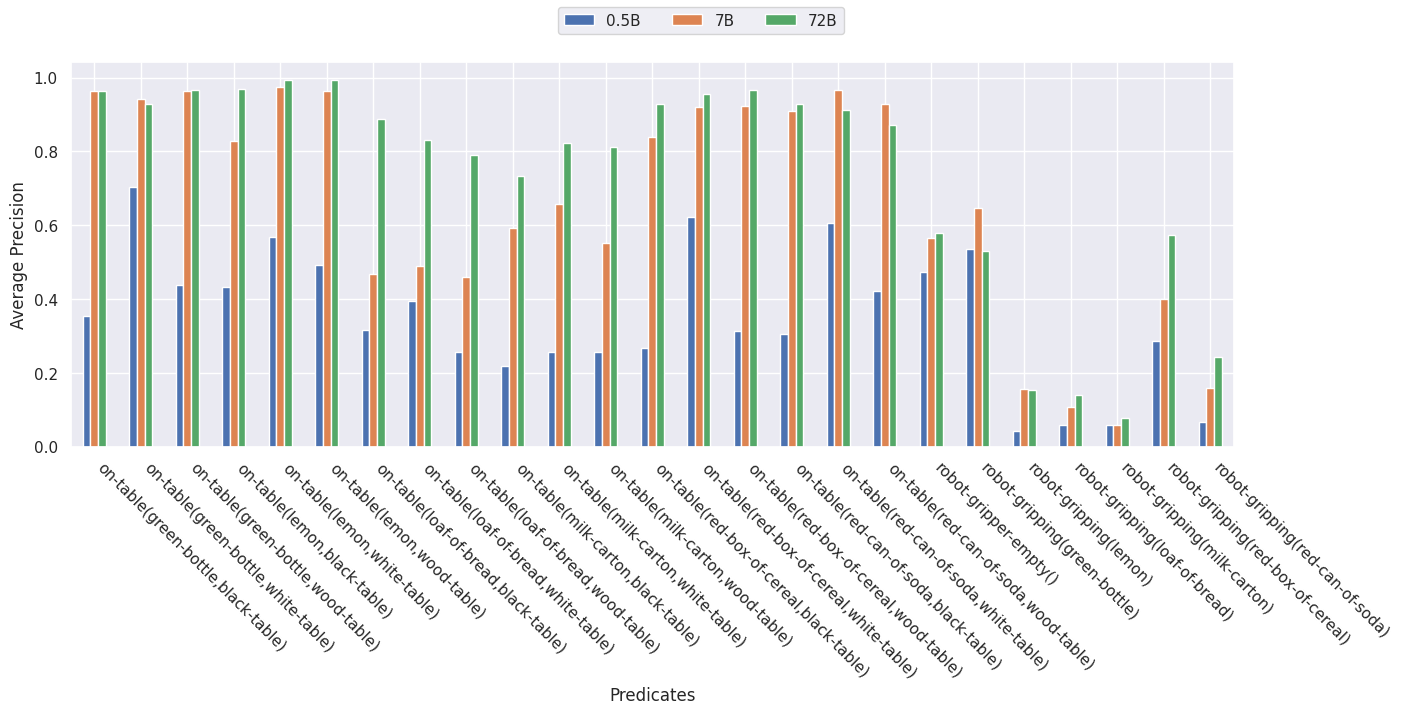

In [11]:
fig, ax = plt.subplots(figsize=(15, 5))
ap_pd = pd.DataFrame.from_dict(average_precision).T.drop(columns=['micro average', 'macro average']).T
ap_pd = ap_pd[['0.5B', '7B', '72B']]

ap_pd.plot.bar(legend=False, ax=ax, color=[color_map[c] for c in ap_pd.columns])

ax.set_ylabel('Average Precision')
ax.set_xlabel('Predicates')
plt.xticks(ha='left', rotation=-45)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4)
fig.savefig('AP_model_sizes.pdf', bbox_inches="tight")

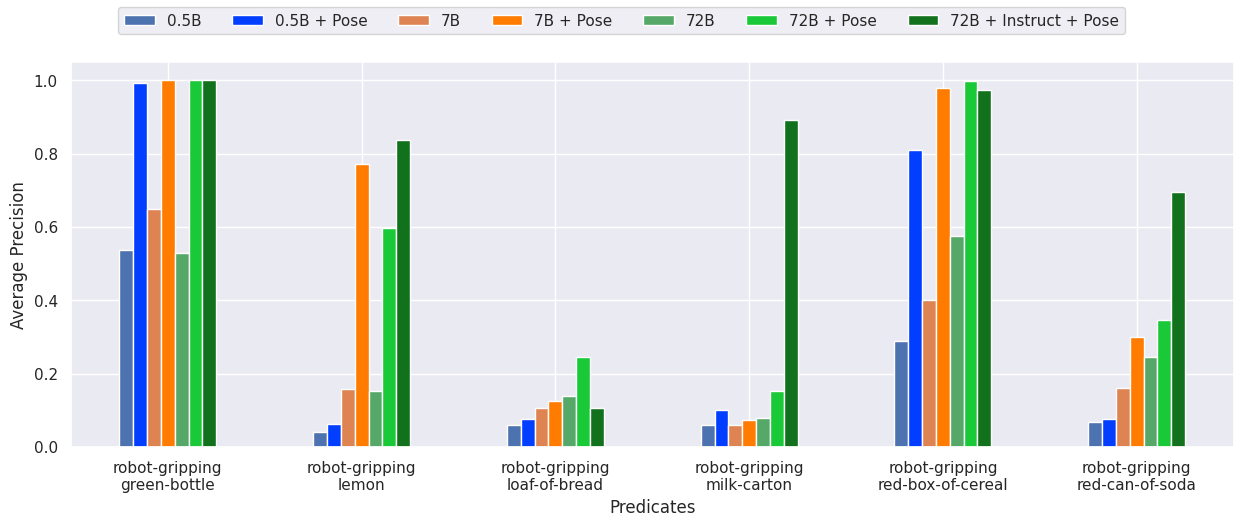

In [12]:
fig, ax = plt.subplots(figsize=(15, 5))
non_robot_preds = [predicate for predicate in next(iter(average_precision.values())) if not predicate.startswith('robot-gripping')]
ap_pd = pd.DataFrame.from_dict(average_precision).T.drop(columns=['micro average', 'macro average'] + non_robot_preds)
ap_pd = ap_pd.T[['0.5B', '0.5B + Pose', '7B', '7B + Pose', '72B', '72B + Pose', '72B + Instruct + Pose']]

ap_pd = ap_pd.T
for col in ap_pd.columns:
    new_col, args = col.split('(')
    new_col += '\n' + args.split(')')[0]
    ap_pd[new_col] = ap_pd[col]
    ap_pd.drop(columns=col, inplace=True)
ap_pd = ap_pd.T

ap_pd.plot.bar(legend=False, ax=ax, color=[color_map[c] for c in ap_pd.columns], rot=0)

ax.set_ylabel('Average Precision')
ax.set_xlabel('Predicates')

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=7)
fig.savefig('AP_home_compare.pdf', bbox_inches="tight")

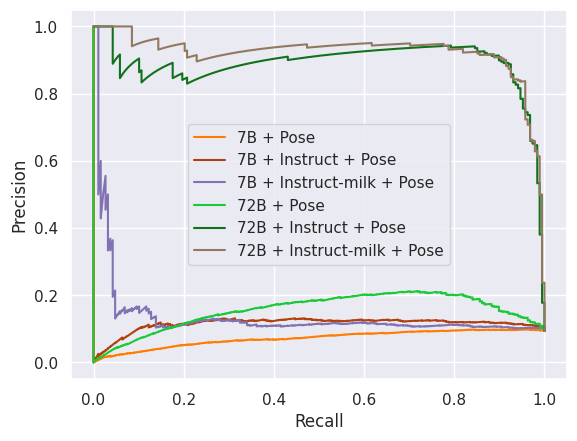

In [13]:
predicate = 'robot-gripping(milk-carton)'

plt.figure()
plt.plot(recall['7B + Pose'][predicate], precision['7B + Pose'][predicate], label='7B + Pose', color=color_map['7B + Pose'])
plt.plot(recall['7B + Instruct + Pose'][predicate], precision['7B + Instruct + Pose'][predicate], label='7B + Instruct + Pose', color=color_map['7B + Instruct + Pose'])
plt.plot(recall['7B + Instruct-milk + Pose'][predicate], precision['7B + Instruct-milk + Pose'][predicate], label='7B + Instruct-milk + Pose', color=color_map['7B + Instruct-milk + Pose'])
plt.plot(recall['72B + Pose'][predicate], precision['72B + Pose'][predicate], label='72B + Pose', color=color_map['72B + Pose'])
plt.plot(recall['72B + Instruct + Pose'][predicate], precision['72B + Instruct + Pose'][predicate], label='72B + Instruct + Pose', color=color_map['72B + Instruct + Pose'])
plt.plot(recall['72B + Instruct-milk + Pose'][predicate], precision['72B + Instruct-milk + Pose'][predicate], label='72B + Instruct-milk + Pose', color=color_map['72B + Instruct-milk + Pose'])

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.savefig('PRC grip milk.pdf', bbox_inches="tight")

In [14]:
table = pd.DataFrame.from_dict({
    'Accuracy ($\theta = 0.3$)': {k: v['average'][30] for k, v in accuracy.items()},
    'Accuracy ($\theta = 0.5$)': {k: v['average'][50] for k, v in accuracy.items()},
    'Accuracy ($\theta = 0.7$)': {k: v['average'][70] for k, v in accuracy.items()},
    'AP Score (micro)': {k: v['micro average'] for k, v in average_precision.items()},
    'AP Score (macro)': {k: v['macro average'] for k, v in average_precision.items()},
}).T[['0.5B', '7B', '72B',
      '0.5B + Instruct', '7B + Instruct', '72B + Instruct',
      '0.5B + Pose', '7B + Pose', '72B + Pose',
      '0.5B + Instruct + Pose', '7B + Instruct + Pose', '72B + Instruct + Pose']]

table.T

,Accuracy ($\theta = 0.3$),Accuracy ($\theta = 0.5$),Accuracy ($\theta = 0.7$),AP Score (micro),AP Score (macro)
0.5B,0.778080,0.792320,0.789760,0.368612,0.350293
7B,0.722220,0.845660,0.877720,0.702188,0.657711
72B,0.815940,0.901900,0.890360,0.813985,0.742143
0.5B + Instruct,0.525680,0.712680,0.755760,0.235278,0.330679
7B + Instruct,0.778360,0.851140,0.853920,0.667612,0.627217
72B + Instruct,0.877592,0.921341,0.888427,0.802112,0.780631
0.5B + Pose,0.781580,0.783480,0.781700,0.384256,0.426258
7B + Pose,0.739420,0.868180,0.901060,0.764875,0.770890
72B + Pose,0.857020,0.925120,0.909280,0.872449,0.830831
0.5B + Instruct + Pose,0.534460,0.707620,0.749660,0.243711,0.417184


In [15]:
print(table.T.to_latex(float_format="%.2f"))

\begin{tabular}{lrrrrr}
\toprule
 & Accuracy ($	heta = 0.3$) & Accuracy ($	heta = 0.5$) & Accuracy ($	heta = 0.7$) & AP Score (micro) & AP Score (macro) \\
\midrule
0.5B & 0.78 & 0.79 & 0.79 & 0.37 & 0.35 \\
7B & 0.72 & 0.85 & 0.88 & 0.70 & 0.66 \\
72B & 0.82 & 0.90 & 0.89 & 0.81 & 0.74 \\
0.5B + Instruct & 0.53 & 0.71 & 0.76 & 0.24 & 0.33 \\
7B + Instruct & 0.78 & 0.85 & 0.85 & 0.67 & 0.63 \\
72B + Instruct & 0.88 & 0.92 & 0.89 & 0.80 & 0.78 \\
0.5B + Pose & 0.78 & 0.78 & 0.78 & 0.38 & 0.43 \\
7B + Pose & 0.74 & 0.87 & 0.90 & 0.76 & 0.77 \\
72B + Pose & 0.86 & 0.93 & 0.91 & 0.87 & 0.83 \\
0.5B + Instruct + Pose & 0.53 & 0.71 & 0.75 & 0.24 & 0.42 \\
7B + Instruct + Pose & 0.81 & 0.86 & 0.86 & 0.73 & 0.73 \\
72B + Instruct + Pose & 0.90 & 0.94 & 0.91 & 0.88 & 0.91 \\
\bottomrule
\end{tabular}



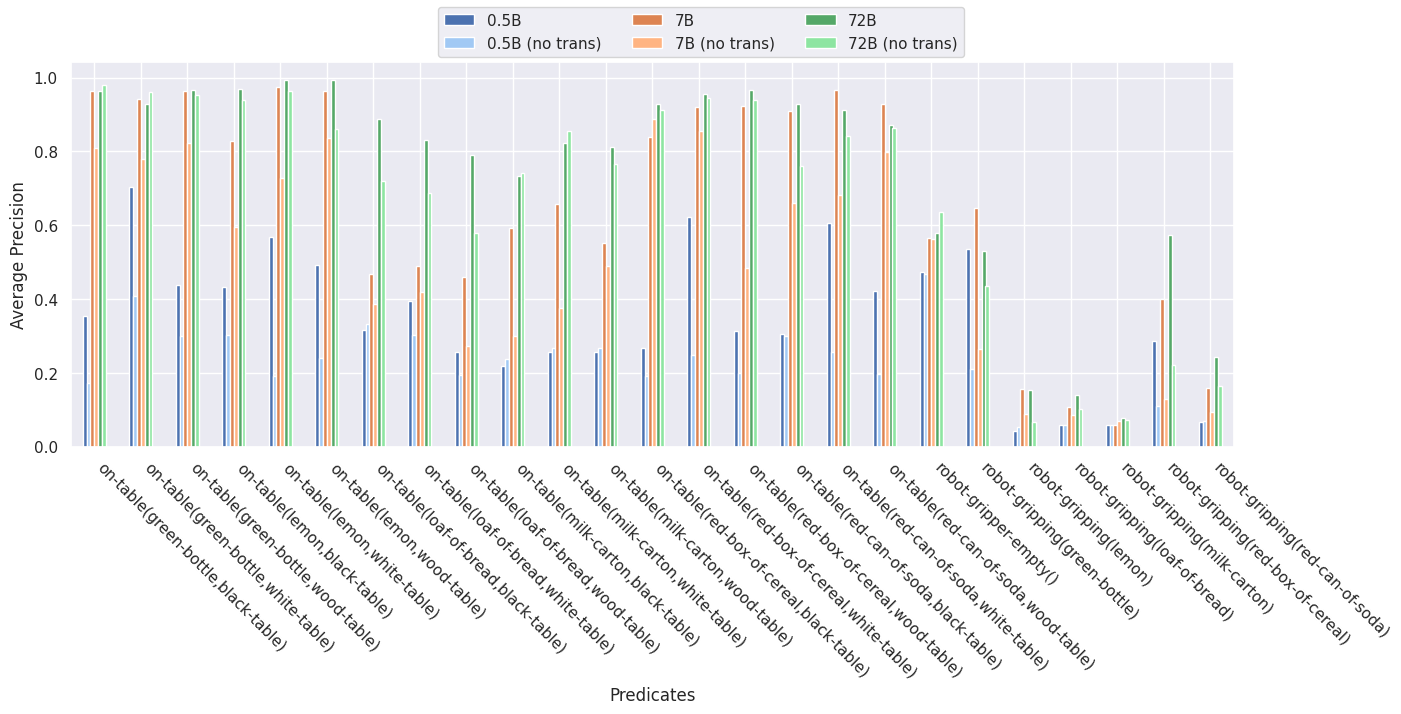

In [16]:
fig, ax = plt.subplots(figsize=(15, 5))
ap_pd = pd.DataFrame.from_dict(average_precision).T.drop(columns=['micro average', 'macro average']).T
ap_pd = ap_pd[['0.5B', '0.5B (no trans)', '7B', '7B (no trans)', '72B', '72B (no trans)']]

ap_pd.plot.bar(legend=False, ax=ax, color=[color_map[c] for c in ap_pd.columns])

ax.set_ylabel('Average Precision')
ax.set_xlabel('Predicates')
plt.xticks(ha='left', rotation=-45)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)
# fig.savefig('AP_model_sizes.pdf', bbox_inches="tight")

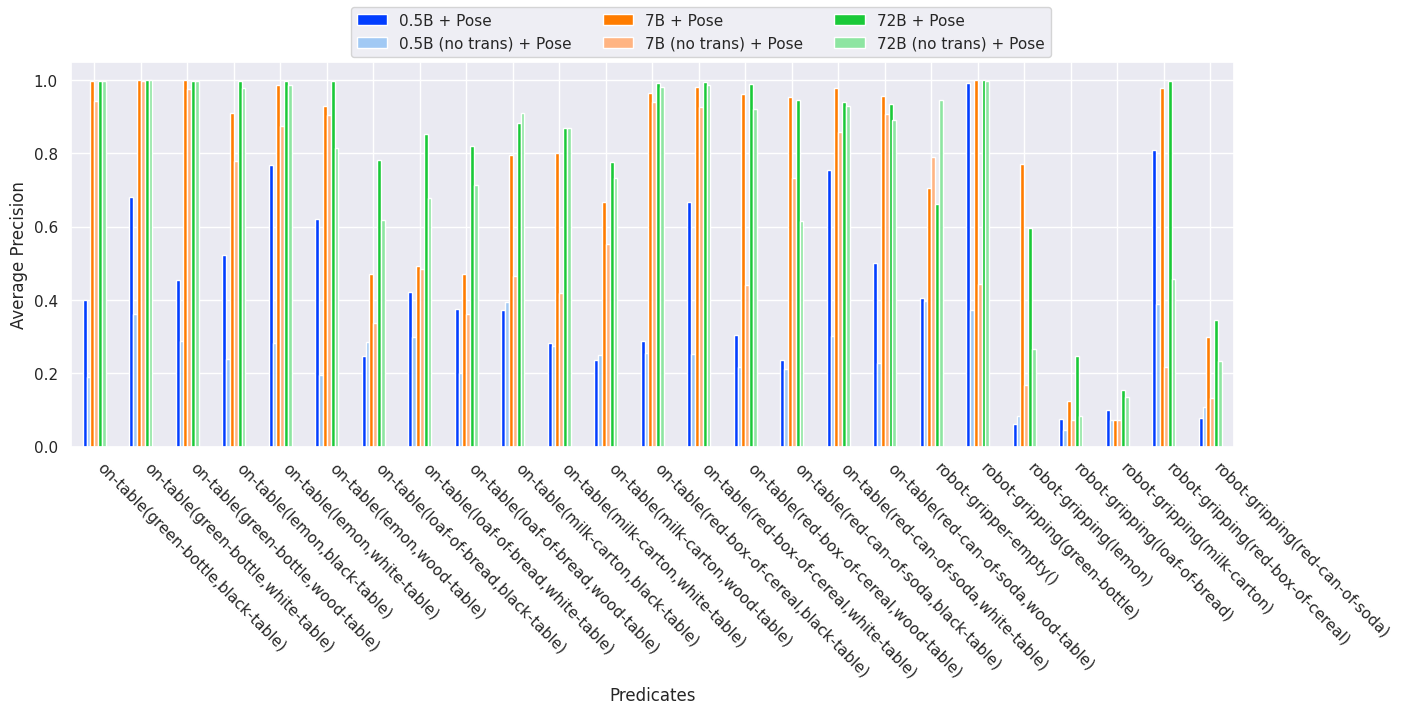

In [17]:
fig, ax = plt.subplots(figsize=(15, 5))
ap_pd = pd.DataFrame.from_dict(average_precision).T.drop(columns=['micro average', 'macro average']).T
ap_pd = ap_pd[['0.5B + Pose', '0.5B (no trans) + Pose', '7B + Pose', '7B (no trans) + Pose', '72B + Pose', '72B (no trans) + Pose']]

ap_pd.plot.bar(legend=False, ax=ax, color=[color_map[c] for c in ap_pd.columns])

ax.set_ylabel('Average Precision')
ax.set_xlabel('Predicates')
plt.xticks(ha='left', rotation=-45)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)
# fig.savefig('AP_model_sizes.pdf', bbox_inches="tight")

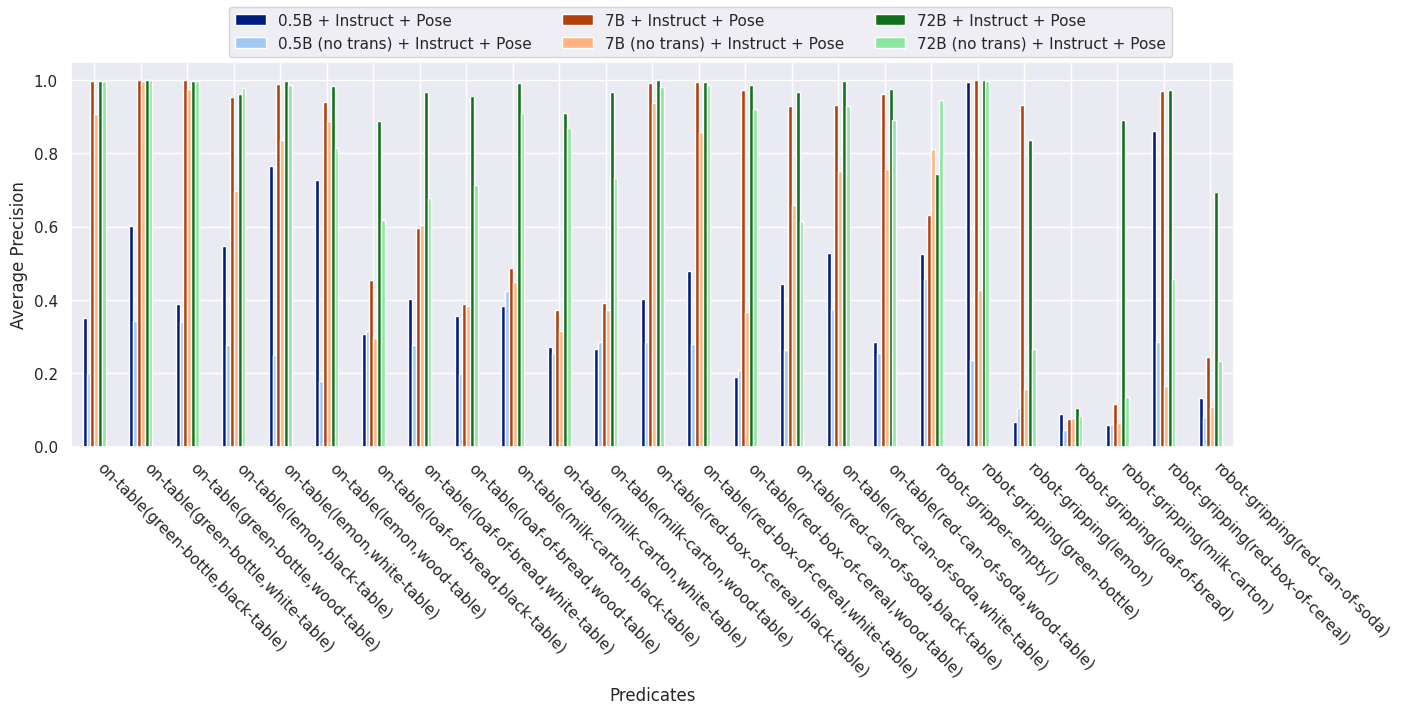

In [18]:
fig, ax = plt.subplots(figsize=(15, 5))
ap_pd = pd.DataFrame.from_dict(average_precision).T.drop(columns=['micro average', 'macro average']).T
ap_pd = ap_pd[['0.5B + Instruct + Pose', '0.5B (no trans) + Instruct + Pose', '7B + Instruct + Pose', '7B (no trans) + Instruct + Pose', '72B + Instruct + Pose', '72B (no trans) + Instruct + Pose']]

ap_pd.plot.bar(legend=False, ax=ax, color=[color_map[c] for c in ap_pd.columns])

ax.set_ylabel('Average Precision')
ax.set_xlabel('Predicates')
plt.xticks(ha='left', rotation=-45)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)
# fig.savefig('AP_model_sizes.pdf', bbox_inches="tight")

In [22]:
table = pd.DataFrame.from_dict({
    'Accuracy ($\theta = 0.3$)': {k: v['average'][30] for k, v in accuracy.items()},
    'Accuracy ($\theta = 0.5$)': {k: v['average'][50] for k, v in accuracy.items()},
    'Accuracy ($\theta = 0.7$)': {k: v['average'][70] for k, v in accuracy.items()},
    'AP Score (micro)': {k: v['micro average'] for k, v in average_precision.items()},
    'AP Score (macro)': {k: v['macro average'] for k, v in average_precision.items()},
}).T[[
    '0.5B', '0.5B (no trans)',
    '7B', '7B (no trans)',
    '72B', '72B (no trans)',
    '0.5B + Pose', '0.5B (no trans) + Pose',
    '7B + Pose', '7B (no trans) + Pose',
    '72B + Pose', '72B (no trans) + Pose',
    '0.5B + Instruct', '0.5B (no trans) + Instruct',
    '7B + Instruct', '7B (no trans) + Instruct',
    '72B + Instruct', '72B (no trans) + Instruct',
    '0.5B + Instruct + Pose', '0.5B (no trans) + Instruct + Pose',
    '7B + Instruct + Pose', '7B (no trans) + Instruct + Pose',
    '72B + Instruct + Pose', '72B (no trans) + Instruct + Pose',
]]

table.T

,Accuracy ($\theta = 0.3$),Accuracy ($\theta = 0.5$),Accuracy ($\theta = 0.7$),AP Score (micro),AP Score (macro)
0.5B,0.778080,0.792320,0.789760,0.368612,0.350293
0.5B (no trans),0.789600,0.789600,0.789600,0.178705,0.225767
7B,0.722220,0.845660,0.877720,0.702188,0.657711
7B (no trans),0.565420,0.630220,0.698380,0.259611,0.499238
72B,0.815940,0.901900,0.890360,0.813985,0.742143
72B (no trans),0.814140,0.871260,0.849980,0.725433,0.678941
0.5B + Pose,0.781580,0.783480,0.781700,0.384256,0.426258
0.5B (no trans) + Pose,0.781420,0.781420,0.781420,0.187753,0.248083
7B + Pose,0.739420,0.868180,0.901060,0.764875,0.770890
7B (no trans) + Pose,0.595120,0.636360,0.698700,0.272924,0.591763


In [23]:
print(table.T.to_latex(float_format="%.2f").replace('\t', '\\t'))

\begin{tabular}{lrrrrr}
\toprule
 & Accuracy ($\theta = 0.3$) & Accuracy ($\theta = 0.5$) & Accuracy ($\theta = 0.7$) & AP Score (micro) & AP Score (macro) \\
\midrule
0.5B & 0.78 & 0.79 & 0.79 & 0.37 & 0.35 \\
0.5B (no trans) & 0.79 & 0.79 & 0.79 & 0.18 & 0.23 \\
7B & 0.72 & 0.85 & 0.88 & 0.70 & 0.66 \\
7B (no trans) & 0.57 & 0.63 & 0.70 & 0.26 & 0.50 \\
72B & 0.82 & 0.90 & 0.89 & 0.81 & 0.74 \\
72B (no trans) & 0.81 & 0.87 & 0.85 & 0.73 & 0.68 \\
0.5B + Pose & 0.78 & 0.78 & 0.78 & 0.38 & 0.43 \\
0.5B (no trans) + Pose & 0.78 & 0.78 & 0.78 & 0.19 & 0.25 \\
7B + Pose & 0.74 & 0.87 & 0.90 & 0.76 & 0.77 \\
7B (no trans) + Pose & 0.60 & 0.64 & 0.70 & 0.27 & 0.59 \\
72B + Pose & 0.86 & 0.93 & 0.91 & 0.87 & 0.83 \\
72B (no trans) + Pose & 0.84 & 0.89 & 0.87 & 0.80 & 0.75 \\
0.5B + Instruct & 0.53 & 0.71 & 0.76 & 0.24 & 0.33 \\
0.5B (no trans) + Instruct & 0.71 & 0.79 & 0.79 & 0.17 & 0.23 \\
7B + Instruct & 0.78 & 0.85 & 0.85 & 0.67 & 0.63 \\
7B (no trans) + Instruct & 0.53 & 0.58 & 0.61 & 0

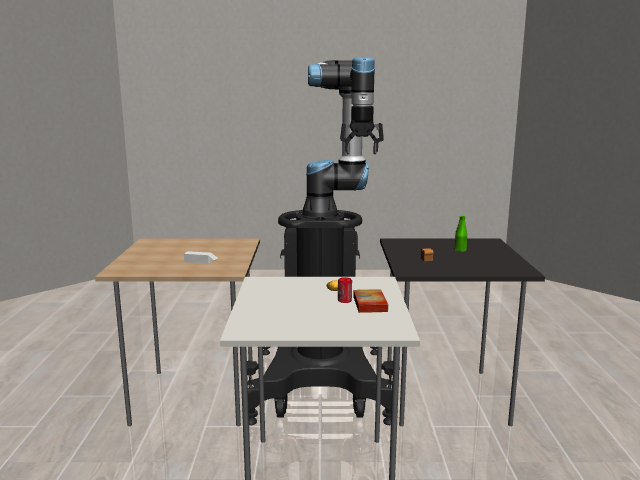

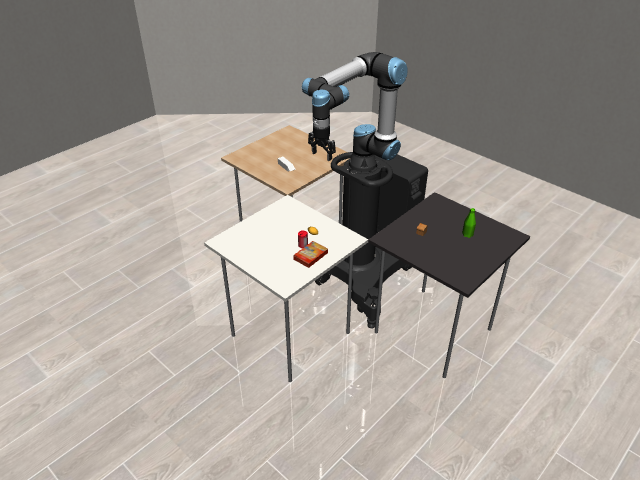

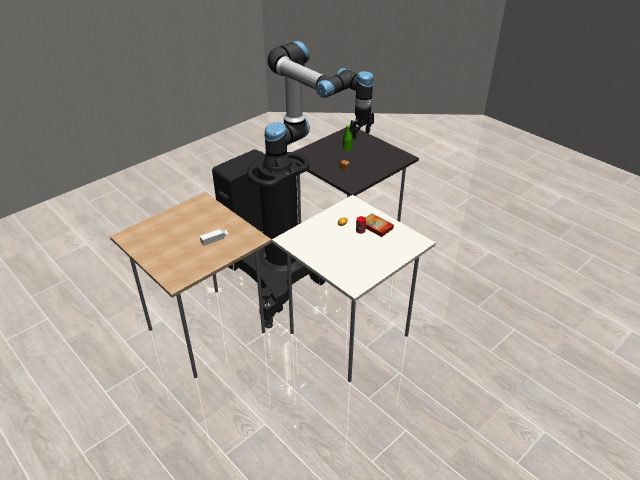

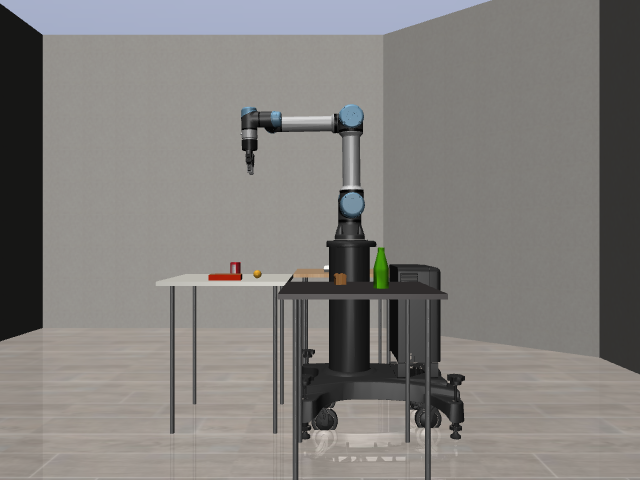

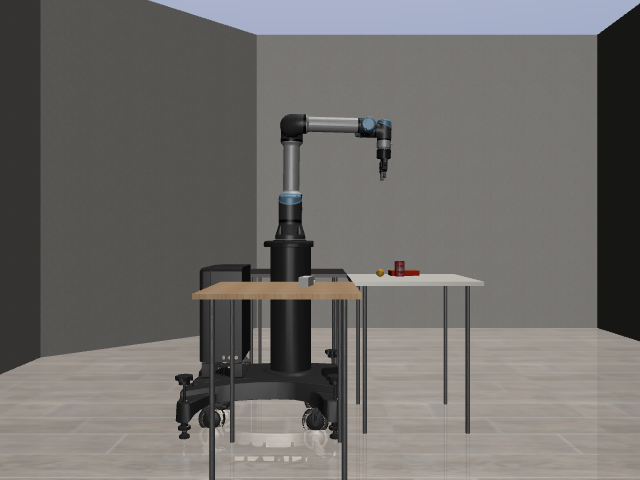

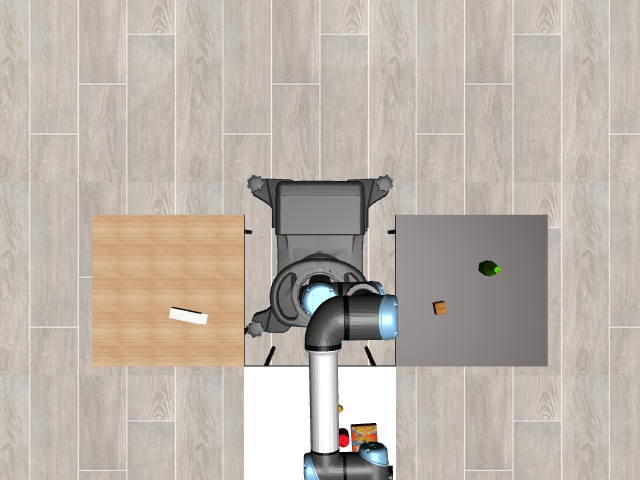

In [19]:
from PIL import Image

dps = [dp for dp, vs in gts_home.items() if vs['robot-gripper-empty()']]
dp_name = np.random.choice(dps)

for k, img_arr in all_renders_home[dp_name].items():
    img = Image.fromarray(img_arr)
    display(img)